# Representação do modelo

## Objetivo

- Aprender a implementar o modelo $f_{w,b} (x)$ para regressão linear com uma variável

## Ferramentas

Nesse código, você usará:
- NumPy, uma biblioteca popular para cálculos matriciais, etc
- Matplotlib, uma biblioteca popular para gerar figuras com dados

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Definição do Problema

Neste notebook, vamos usar um exemplo simples de **regressão linear** para estimar o **custo de uma casa (R$)** a partir da **área (m²)**.

Abaixo está o nosso **conjunto de dados de treinamento** com 20 registros:

| Registro | Área (m²) | Custo (R$) |
|---:|---:|---:|
| 1 | 32 | 51.000 |
| 2 | 45 | 78.000 |
| 3 | 55 | 102.000 |
| 4 | 60 | 118.000 |
| 5 | 68 | 129.000 |
| 6 | 75 | 145.000 |
| 7 | 82 | 158.000 |
| 8 | 90 | 178.000 |
| 9 | 95 | 172.000 |
| 10 | 105 | 198.000 |
| 11 | 110 | 205.000 |
| 12 | 120 | 219.000 |
| 13 | 130 | 238.000 |
| 14 | 140 | 252.000 |
| 15 | 149 | 265.000 |
| 16 | 160 | 287.000 |
| 17 | 170 | 292.000 |
| 18 | 180 | 305.000 |
| 19 | 200 | 318.000 |
| 20 | 220 | 335.000 |

A ideia é ajustar uma reta do tipo **f(x) = w·x + b** para aproximar essa relação.


Rode a célula de código abaixo para criar as variáveis `x_trein` (área) e `y_trein` (custo). Os dados são armazenados em arrays NumPy de uma dimensão.

In [ ]:
import numpy as np
import pandas as pd

df = pd.read_csv('/content/sample_data/arquivos/tabela_multivariavel_imoveis_500.csv', sep=',')

x1_trein = df['AreaEX'].values
x2_trein = df['QuartosEx'].values
x3_trein = df['BanheirosEx'].values
x4_trein = df['IdadeEx'].values
x5_trein = df['DistanciaEx'].values
y_trein = df['PrecoEx'].values

print(f"x1_trein (Area) = {x1_trein}")
print(f"x2_trein (Quartos) = {x2_trein}")
print(f"x3_trein (Banheiro) = {x3_trein}")
print(f"x4_trein (Idade) = {x4_trein}")
print(f"x5_trein (Distancia) = {x5_trein}")
print(f"y_trein (Preco) = {y_trein}")

ParserError: Error tokenizing data. C error: Expected 8 fields in line 3, saw 9


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

### Número de amostras de treinamento `m`

Usaremos `m` para denotar o número de amostras de treinamento. Numpy arrays têm o parâmetro `.shape`. Nesse contexto, `x_train.shape` retorna uma tupla com uma entrada para cada dimensão. `x_train.shape[0]` é o comprimento da array (primeiro elemento presente na tupla), conforme mostrado abaixo.

In [ ]:
# m é o número de amostras de treinamento
print(f"x_trein.shape: {x1_trein.shape}")
m = x1_trein.shape[0]
print(f"O número de amostras de treinamento é: {m}")

# m é o número de amostras de treinamento
print(f"x_trein.shape: {x2_trein.shape}")
m = x2_trein.shape[0]
print(f"O número de amostras de treinamento é: {m}")

# m é o número de amostras de treinamento
print(f"x_trein.shape: {x3_trein.shape}")
m = x3_trein.shape[0]
print(f"O número de amostras de treinamento é: {m}")

# m é o número de amostras de treinamento
print(f"x_trein.shape: {x4_trein.shape}")
m = x4_trein.shape[0]
print(f"O número de amostras de treinamento é: {m}")

# m é o número de amostras de treinamento
print(f"x_trein.shape: {x5_trein.shape}")
m = x5_trein.shape[0]
print(f"O número de amostras de treinamento é: {m}")

x_trein.shape: (500,)
O número de amostras de treinamento é: 500
x_trein.shape: (500,)
O número de amostras de treinamento é: 500
x_trein.shape: (500,)
O número de amostras de treinamento é: 500
x_trein.shape: (500,)
O número de amostras de treinamento é: 500
x_trein.shape: (500,)
O número de amostras de treinamento é: 500


É possível também utilizar o função em Python `len()`, conforme abaixo.

In [ ]:
m = len(x2_trein)
print(f"O número de amostras de treinamento é: {m}")

O número de amostras de treinamento é: 500


### Amostra de treinamento `x_i, y_i`

Usaremos (x$^{(i)}$, y$^{(i)}$) para denotar a **i-ésima amostra** do conjunto de treinamento.

Como o Python começa em índice 0, por exemplo:

- (x$^{(0)}$, y$^{(0)}$) = (32, 51000)
- (x$^{(1)}$, y$^{(1)}$) = (45, 78000)

A i-ésima posição do array `x_trein` é acessada com `x_trein[i]` (e o custo correspondente com `y_trein[i]`).

Veja o código abaixo.


In [ ]:
i = 0 # Mude esse valor para 1 para ver (x^1, y^1)

x_i = x1_trein[i]
x_i = x2_trein[i]
x_i = x3_trein[i]
x_i = x4_trein[i]
x_i = x5_trein[i]
y_i = y_trein[i]
print(f"(x^({i}), y^({i})) = ({x_i}, {y_i})")

(x^(0), y^(0)) = (30,00, 147.688,39)


### Plotando os dados (gerando uma figura que mostra os dados)

Você pode plotar os dois pontos usando a função `scatter()` presente na biblioteca `matplotlib`, conforme mostrado abaixo.
- Os argumentos `marker` e `c` mostram os pontos como 'x' vermelhos (o padrão são pontos azuis).

Você pode usar outras funções da biblioteca `matplotlib` para definir o título e os rótulos dos eixos

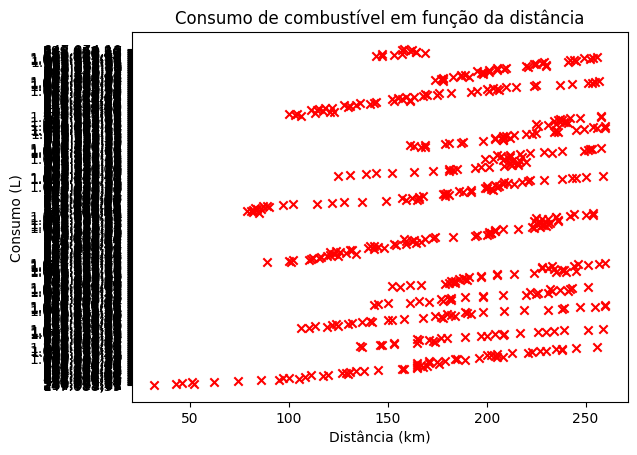

In [ ]:
import matplotlib.pyplot as plt

# Plotando os pontos dos dados
plt.scatter(x1_trein, y_trein, marker='x', c='r')
# Ajustando o título:
plt.title("Consumo de combustível em função da distância")
# Ajustando o rótulo do eixo y
plt.ylabel('Consumo (L)')
# Ajustando o rótulo do eixo x
plt.xlabel('Distância (km)')
plt.show()

## Implementando um modelo

O modelo de função para regressão linear (que é a função que faz o mapeamento de `x` para `y`) é representado por

$$ f_{w,b}(x^{(i)}) = wx^{(i)} + b \tag{1}$$

A fórmula acima nos mostra a equação da reta: diferentes valores para $w$ e $b$ levam a diferentes retas. <br/> <br/> <br/> <br/> <br/>


Vamos tentar ganhar mais intuição usando o código abaixo. Vamos começar com $w = 0$ e $b = 100$.

**OBS: Você pode retornar à célula abaixo para ajustar diferentes valores para os parâmetros w e b do modelo**

In [ ]:
w = 1200
b = 16000
print(f"w: {w}")
print(f"b: {b}")

w: 1200
b: 16000


Agora, vamos computar o valor $f_{w,b}(x^{(i)})$ para os dois dados que temos. Você pode explicitamente escrever:

para $x^{(0)}$, `f_wb = w * x[0] + b`

para $x^{(1)}$, `f_wb = w * x[1] + b`

Para uma grande quantidade de dados, isso pode ser demasiadamente repetitivo. Ao invés disso, você pode usar um loop do tipo `for` conforme mostrado na função `calcula_saida_do_modelo` abaixo.
> **OBS**: O argumento `(ndarray (m,))` descreve uma Numpy array de n dimensões da forma (m,). `(scalar)` descreve um argumento sem dimensões, apenas uma magnitude.  
> **OBS**: `np.zero(n)` retorna uma numpy array de 1 dimensão com $n$ valores   


In [ ]:
def calcula_saida_do_modelo(x, w, b):
    """
    Calcula a previsão para um modelo na forma de reta
    Argumentos da função:
      x (ndarray (m,)): Conjunto de dados com m amostras
      w,b (escalar)   : Parâmetros do modelo
    Retorna
      y (ndarray (m,)): Previsão de saída
    """
    m = x.shape[0]
    f_wb = np.zeros(m)
    for i in range(m): # estrutura 'for' em Python
        f_wb[i] = w * x[i] + b

    return f_wb

Agora vamos chamar a função `calcula_saida_do_modelo` e plotar o resultado

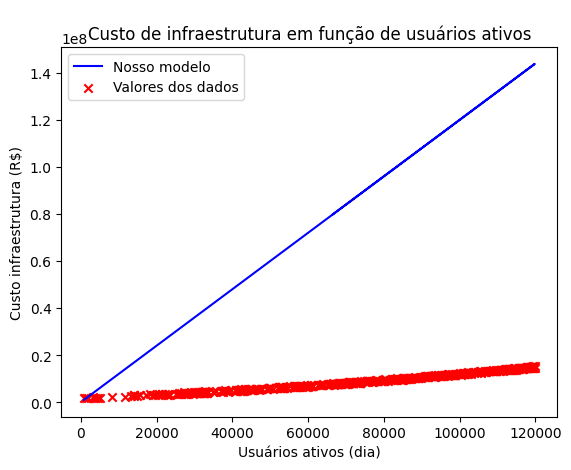

In [ ]:
f_wb_calculado = calcula_saida_do_modelo(x_trein, w, b,)

# Plotando a previsão feita pelo modelo
plt.plot(x_trein, f_wb_calculado, c='b',label='Nosso modelo')

# Plotando os dados medidos
plt.scatter(x_trein, y_trein, marker='x', c='r',label='Valores dos dados')

# Definindo o título
plt.title("Custo de infraestrutura em função de usuários ativos")
# Ajustando o rótulo do eixo y
plt.ylabel('Custo infraestrutura (R$)')
# Ajustando o rótulo do eixo x
plt.xlabel('Usuários ativos (dia)')
plt.legend()
plt.show()


Como você pode ver, definindo $w = 0$ e $b = 100$ *não* resulta numa reta que se ajusta bem aos nossos dados.

### Desafio
Tente diferentes valores para $w$ e $b$. Quais seriam os melhores valores para esse conjunto de dados?

Qual seria uma possível interpretação física para o parâmetro $w$ nesse exemplo?


### Previsão

Agora que temos um modelo, podemos usá-lo para fazer uma previsão para uma casa com **uma área diferente**.
Vamos estimar o custo para uma casa de **100 m²**.


In [ ]:
w = 10
b = 100
x_i = 1  # área em m²
custo_estimado = w * x_i + b

print(f"R$ {custo_estimado:,.0f}".replace(',', '.'))


R$ 110
